## Part A - Image Feature Extraction and Classification

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import sklearn

In [71]:
from pathlib import Path

crack_folder = Path("data/images/cracks")
non_crack_folder = Path("data/images/noncracks")

crack_images = list(crack_folder.iterdir())
non_crack_images = list(non_crack_folder.iterdir())

print("Crack images:", len(crack_images))
print("Non-crack images:", len(non_crack_images))
print("Total images:", len(crack_images) + len(non_crack_images))

Crack images: 200
Non-crack images: 200
Total images: 400


In [72]:
sample_path = crack_images[0]

image = cv2.imread(str(sample_path))

print("Image loaded:", image is not None)
print("Image shape:", image.shape)

Image loaded: True
Image shape: (448, 448, 3)


In [73]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Grayscale shape:", gray.shape)
print("Minimum intensity:", gray.min())
print("Maximum intensity:", gray.max())

Grayscale shape: (448, 448)
Minimum intensity: 0
Maximum intensity: 255


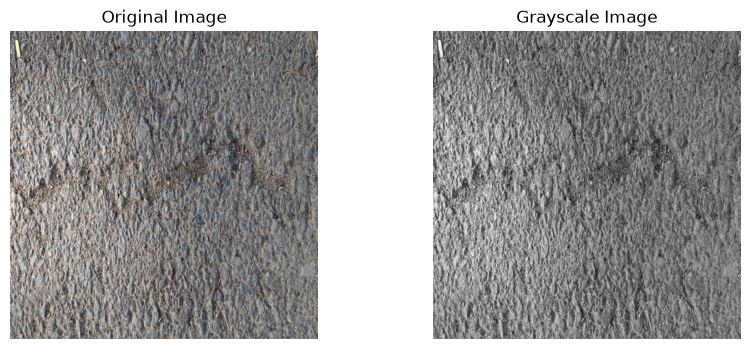

In [74]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

In [75]:
image_shapes = []

for file in crack_images + non_crack_images:
    img = cv2.imread(str(file))
    
    if img is not None:
        image_shapes.append(img.shape)

print("Number of successfully loaded images:", len(image_shapes))
print("Unique image shapes:", set(image_shapes))

Number of successfully loaded images: 400
Unique image shapes: {(448, 448, 3)}


In [76]:
resized = cv2.resize(image, (224, 224))

print("Original shape:", image.shape)
print("Resized shape:", resized.shape)

Original shape: (448, 448, 3)
Resized shape: (224, 224, 3)


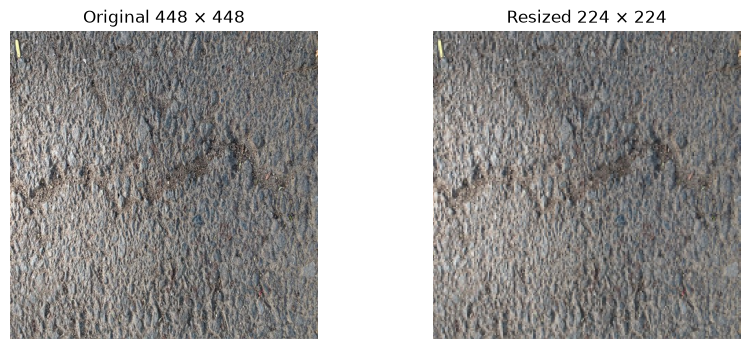

In [77]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original 448 × 448")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized 224 × 224")
plt.axis("off")

plt.show()

In [78]:
gray_resized = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

print("Grayscale shape:", gray_resized.shape)

Grayscale shape: (224, 224)


In [79]:
mean_brightness = np.mean(gray_resized)

print("Mean brightness:", mean_brightness)

Mean brightness: 122.224609375


In [80]:
contrast = np.std(gray_resized)

print("Contrast:", contrast)

Contrast: 31.51348191896166


In [81]:
dark_threshold = 50

dark_pixels = gray_resized < dark_threshold
dark_pixel_ratio = np.mean(dark_pixels)

print("Dark-pixel ratio:", dark_pixel_ratio)

Dark-pixel ratio: 0.0038464604591836736


In [82]:
bright_threshold = 200

bright_pixels = gray_resized > bright_threshold
bright_pixel_ratio = np.mean(bright_pixels)

print("Bright-pixel ratio:", bright_pixel_ratio)

Bright-pixel ratio: 0.01092155612244898


In [83]:
edges = cv2.Canny(gray_resized, 100, 200)

print("Edge image shape:", edges.shape)

Edge image shape: (224, 224)


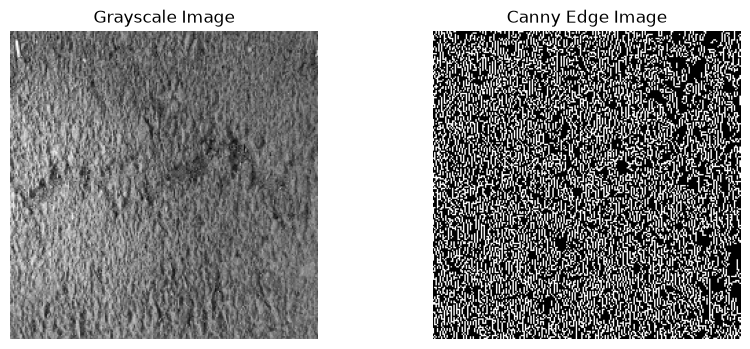

In [84]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_resized, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")

plt.show()

In [85]:
edge_pixels = edges > 0
edge_count = np.sum(edge_pixels)

total_pixels = gray_resized.size
edge_density = edge_count / total_pixels

print("Edge count:", edge_count)
print("Total pixels:", total_pixels)
print("Edge density:", edge_density)

Edge count: 17232
Total pixels: 50176
Edge density: 0.3434311224489796


In [86]:
min_intensity = np.min(gray_resized)
max_intensity = np.max(gray_resized)
median_intensity = np.median(gray_resized)

print("Minimum intensity:", min_intensity)
print("Maximum intensity:", max_intensity)
print("Median intensity:", median_intensity)

Minimum intensity: 23
Maximum intensity: 247
Median intensity: 121.0


In [87]:
feature_row = {
    "image": sample_path.name,
    "label": 1,
    "mean_brightness": mean_brightness,
    "contrast": contrast,
    "dark_pixel_ratio": dark_pixel_ratio,
    "bright_pixel_ratio": bright_pixel_ratio,
    "min_intensity": min_intensity,
    "max_intensity": max_intensity,
    "median_intensity": median_intensity,
    "edge_count": edge_count,
    "edge_density": edge_density
}

print(feature_row)

{'image': 'IMG_20180513_164959951_HDR resized_448.jpg', 'label': 1, 'mean_brightness': np.float64(122.224609375), 'contrast': np.float64(31.51348191896166), 'dark_pixel_ratio': np.float64(0.0038464604591836736), 'bright_pixel_ratio': np.float64(0.01092155612244898), 'min_intensity': np.uint8(23), 'max_intensity': np.uint8(247), 'median_intensity': np.float64(121.0), 'edge_count': np.int64(17232), 'edge_density': np.float64(0.3434311224489796)}


In [88]:
sample_df = pd.DataFrame([feature_row])

sample_df

,image,label,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density
0,IMG_20180513_164959951_HDR resized_448.jpg,1,122.224609,31.513482,0.003846,0.010922,23,247,121.0,17232,0.343431


In [89]:
def extract_image_features(image_path, label):
    # Read image
    image = cv2.imread(str(image_path))

    # Check whether image was loaded
    if image is None:
        return None

    # Resize
    resized = cv2.resize(image, (224, 224))

    # Convert to grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Intensity features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    # Canny edge detection
    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / gray.size

    # Return all features
    return {
        "image": image_path.name,
        "label": label,
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

In [90]:
test_features = extract_image_features(crack_images[0], 1)

print(test_features)

{'image': 'IMG_20180513_164959951_HDR resized_448.jpg', 'label': 1, 'mean_brightness': np.float64(122.224609375), 'contrast': np.float64(31.51348191896166), 'dark_pixel_ratio': np.float64(0.0038464604591836736), 'bright_pixel_ratio': np.float64(0.01092155612244898), 'min_intensity': np.uint8(23), 'max_intensity': np.uint8(247), 'median_intensity': np.float64(121.0), 'edge_count': np.int64(17232), 'edge_density': np.float64(0.3434311224489796)}


In [91]:
test_df = pd.DataFrame([test_features])

test_df

,image,label,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density
0,IMG_20180513_164959951_HDR resized_448.jpg,1,122.224609,31.513482,0.003846,0.010922,23,247,121.0,17232,0.343431


In [92]:
all_features = []

In [93]:
image_features_df = pd.DataFrame(all_features)

print("Shape:", image_features_df.shape)
image_features_df.head()

Shape: (0, 0)


""


In [94]:
for image_path in crack_images:
    features = extract_image_features(image_path, 1)

    if features is not None:
        all_features.append(features)

print("After crack images:", len(all_features))

After crack images: 200


In [95]:
for image_path in non_crack_images:
    features = extract_image_features(image_path, 0)

    if features is not None:
        all_features.append(features)

print("Total feature rows:", len(all_features))

Total feature rows: 400


In [96]:
image_features_df = pd.DataFrame(all_features)

print("Shape:", image_features_df.shape)
image_features_df.head()

Shape: (400, 11)


,image,label,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density
0,IMG_20180513_164959951_HDR resized_448.jpg,1,122.224609,31.513482,0.003846,0.010922,23,247,121.0,17232,0.343431
1,IMG_20180513_165129852_HDR resized_448.jpg,1,131.948681,24.096114,0.002790,0.003787,8,251,133.0,13394,0.266940
2,IMG_20180513_165150613_HDR resized_448.jpg,1,121.297313,29.884272,0.013333,0.008171,2,241,121.0,13185,0.262775
3,IMG_20180513_165345878_HDR resized_448.jpg,1,130.245596,25.649018,0.001893,0.004006,20,253,131.0,16591,0.330656
4,IMG_20180513_165349788_HDR resized_448.jpg,1,131.208885,26.237598,0.002372,0.006258,11,254,132.0,15886,0.316606


In [97]:
print(image_features_df["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


In [98]:
print("Shape:", image_features_df.shape)

Shape: (400, 11)


In [99]:
image_features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   image               400 non-null    str    
 1   label               400 non-null    int64  
 2   mean_brightness     400 non-null    float64
 3   contrast            400 non-null    float64
 4   dark_pixel_ratio    400 non-null    float64
 5   bright_pixel_ratio  400 non-null    float64
 6   min_intensity       400 non-null    uint8  
 7   max_intensity       400 non-null    uint8  
 8   median_intensity    400 non-null    float64
 9   edge_count          400 non-null    int64  
 10  edge_density        400 non-null    float64
dtypes: float64(6), int64(2), str(1), uint8(2)
memory usage: 40.9 KB


In [100]:
image_features_df.to_csv("outputs/image_features.csv", index=False)

print("Image feature table saved successfully.")

Image feature table saved successfully.


In [101]:
from pathlib import Path

output_file = Path("outputs/image_features.csv")

print("File exists:", output_file.exists())
print("File size:", output_file.stat().st_size, "bytes")

File exists: True
File size: 57399 bytes


In [102]:
sample_path = crack_images[0]

original = cv2.imread(str(sample_path))
resized_sample = cv2.resize(original, (224, 224))
gray_sample = cv2.cvtColor(resized_sample, cv2.COLOR_BGR2GRAY)
edges_sample = cv2.Canny(gray_sample, 100, 200)

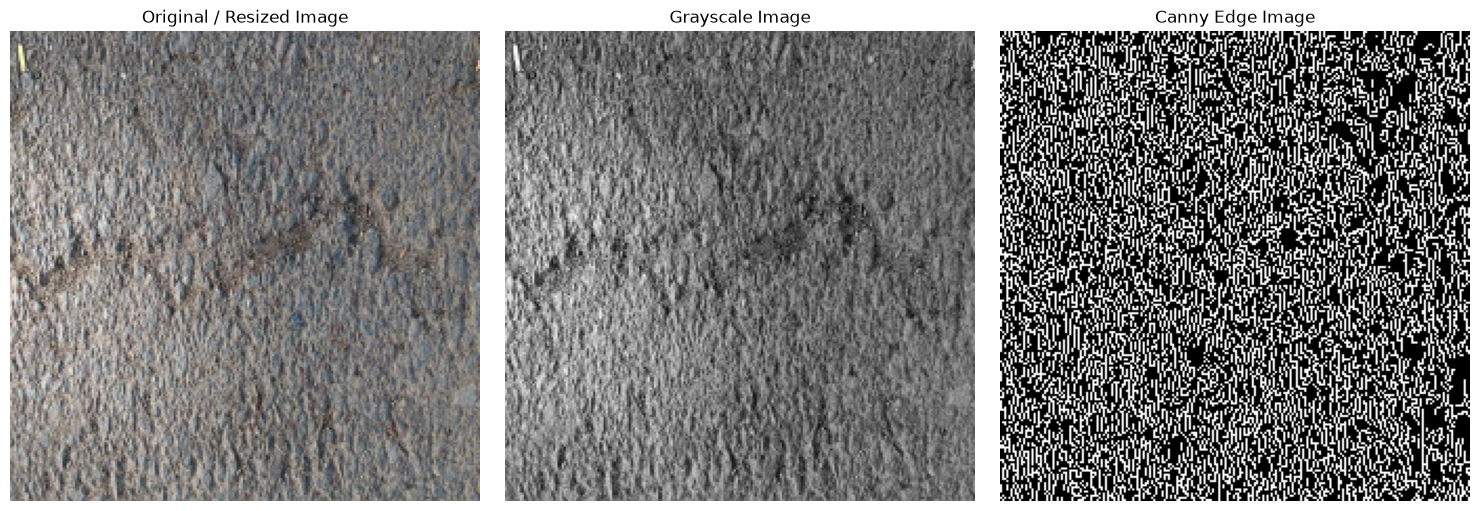

In [103]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(resized_sample, cv2.COLOR_BGR2RGB))
plt.title("Original / Resized Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_sample, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges_sample, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [104]:
feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "edge_count",
    "edge_density"
]

X = image_features_df[feature_columns]
y = image_features_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 9)
y shape: (400,)


In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (320, 9)
X_test: (80, 9)
y_train: (320,)
y_test: (80,)


In [106]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
label
1    160
0    160
Name: count, dtype: int64

Testing class distribution:
label
0    40
1    40
Name: count, dtype: int64


In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (320, 9)
Scaled testing shape: (80, 9)


In [108]:
print("Training feature means:")
print(X_train_scaled.mean(axis=0))

Training feature means:
[-1.13797860e-16 -2.47024623e-16  7.77156117e-17  4.99600361e-17
  8.32667268e-18 -1.80411242e-17 -6.41153797e-16  1.38777878e-17
  1.94289029e-16]


In [109]:
print("\nTraining feature standard deviations:")
print(X_train_scaled.std(axis=0))


Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [110]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [111]:
y_pred = logistic_model.predict(X_test_scaled)

print("Predictions:", y_pred[:10])

Predictions: [0 1 1 0 1 0 0 0 0 1]


In [112]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9375


In [113]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.926829268292683


In [114]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.95


In [115]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.9382716049382716


In [116]:
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Logistic Regression Results
---------------------------
Accuracy : 0.9375
Precision: 0.926829268292683
Recall   : 0.95
F1-score : 0.9382716049382716


In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[37  3]
 [ 2 38]]


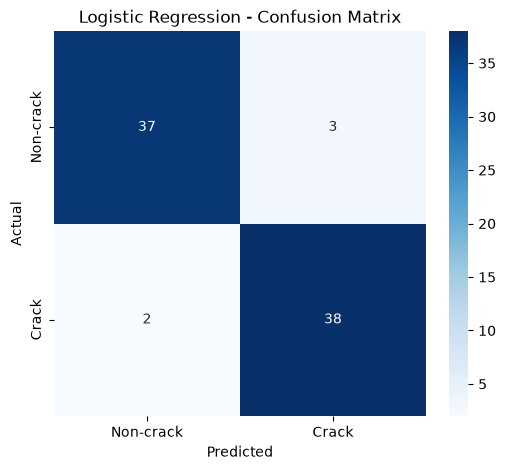

In [118]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-crack", "Crack"],
    yticklabels=["Non-crack", "Crack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [119]:
import time

start_train = time.perf_counter()

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

train_time = time.perf_counter() - start_train

start_pred = time.perf_counter()

y_pred = logistic_model.predict(X_test_scaled)

prediction_time = time.perf_counter() - start_pred

print("Training time:", train_time, "seconds")
print("Prediction time:", prediction_time, "seconds")

Training time: 0.08535259999916889 seconds
Prediction time: 0.002449499996146187 seconds


In [120]:
from sklearn.ensemble import RandomForestClassifier
import time

start_train = time.perf_counter()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_train_time = time.perf_counter() - start_train

start_pred = time.perf_counter()

rf_pred = rf_model.predict(X_test)

rf_prediction_time = time.perf_counter() - start_pred

print("Random Forest trained successfully.")
print("Training time:", rf_train_time, "seconds")
print("Prediction time:", rf_prediction_time, "seconds")

Random Forest trained successfully.
Training time: 1.7973912000015844 seconds
Prediction time: 0.13458949999767356 seconds


In [121]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

Random Forest Results
--------------------
Accuracy : 0.95
Precision: 0.95
Recall   : 0.95
F1-score : 0.95


In [122]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[38  2]
 [ 2 38]]


### Part A Observation

The asphalt images were converted into numerical features using image intensity statistics and Canny edge detection. Logistic Regression achieved 93.75% accuracy, while Random Forest achieved 95.00% accuracy on the test set. Both models were evaluated using accuracy, precision, recall, F1-score, confusion matrices, training time, and prediction time.

# Part B - Text Vectorization and Spam Classification

In [127]:
import pandas as pd

emails_df = pd.read_csv("data/text/emails.csv")

print("Dataset shape:", emails_df.shape)
emails_df.head()

Dataset shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [128]:
print("Columns:")
print(emails_df.columns.tolist())

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'net', 

In [129]:
print("\nMissing values:")
print(emails_df.isnull().sum())


Missing values:
Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64


In [130]:
print("\nData types:")
print(emails_df.dtypes)


Data types:
Email No.       str
the           int64
to            int64
ect           int64
and           int64
              ...  
military      int64
allowing      int64
ff            int64
dry           int64
Prediction    int64
Length: 3002, dtype: object


In [131]:
print("Dataset shape:", emails_df.shape)
print(emails_df["Prediction"].value_counts())
print(emails_df["Prediction"].value_counts(normalize=True) * 100)

Dataset shape: (5172, 3002)
Prediction
0    3672
1    1500
Name: count, dtype: int64
Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64


In [132]:
text_feature_columns = [
    col for col in emails_df.columns
    if col not in ["Email No.", "Prediction"]
]

X_text = emails_df[text_feature_columns]
y_text = emails_df["Prediction"]

print("X shape:", X_text.shape)
print("y shape:", y_text.shape)

X shape: (5172, 3000)
y shape: (5172,)


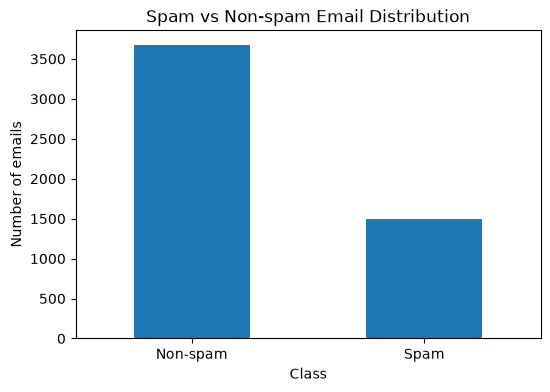

In [133]:
plt.figure(figsize=(6, 4))

emails_df["Prediction"].value_counts().sort_index().plot(kind="bar")

plt.xticks([0, 1], ["Non-spam", "Spam"], rotation=0)
plt.xlabel("Class")
plt.ylabel("Number of emails")
plt.title("Spam vs Non-spam Email Distribution")

plt.show()

In [136]:
X_text[["the", "to", "free", "spam", "click"]].head()

,the,to,free,spam,click
0,0,0,0,0,0
1,8,13,0,0,0
2,0,0,0,0,0
3,0,5,0,0,0
4,7,6,0,0,0


In [137]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=42,
    stratify=y_text
)

print("Training features:", X_text_train.shape)
print("Testing features:", X_text_test.shape)

print("\nTraining labels:")
print(y_text_train.value_counts())

print("\nTesting labels:")
print(y_text_test.value_counts())

Training features: (4137, 3000)
Testing features: (1035, 3000)

Training labels:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing labels:
Prediction
0    735
1    300
Name: count, dtype: int64


In [138]:
from sklearn.naive_bayes import MultinomialNB
import time

start = time.perf_counter()

nb_model = MultinomialNB()
nb_model.fit(X_text_train, y_text_train)

nb_train_time = time.perf_counter() - start

start = time.perf_counter()

nb_pred = nb_model.predict(X_text_test)

nb_prediction_time = time.perf_counter() - start

print("Multinomial Naive Bayes trained successfully.")
print("Training time:", nb_train_time, "seconds")
print("Prediction time:", nb_prediction_time, "seconds")

Multinomial Naive Bayes trained successfully.
Training time: 1.2135523000033572 seconds
Prediction time: 0.5649567000000388 seconds


In [139]:
nb_accuracy = accuracy_score(y_text_test, nb_pred)
nb_precision = precision_score(y_text_test, nb_pred)
nb_recall = recall_score(y_text_test, nb_pred)
nb_f1 = f1_score(y_text_test, nb_pred)

In [140]:
print("Multinomial Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1-score :", nb_f1)

Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.9420289855072463
Precision: 0.8680981595092024
Recall   : 0.9433333333333334
F1-score : 0.9041533546325878


In [141]:
nb_cm = confusion_matrix(y_text_test, nb_pred)

print("Confusion Matrix:")
print(nb_cm)

Confusion Matrix:
[[692  43]
 [ 17 283]]


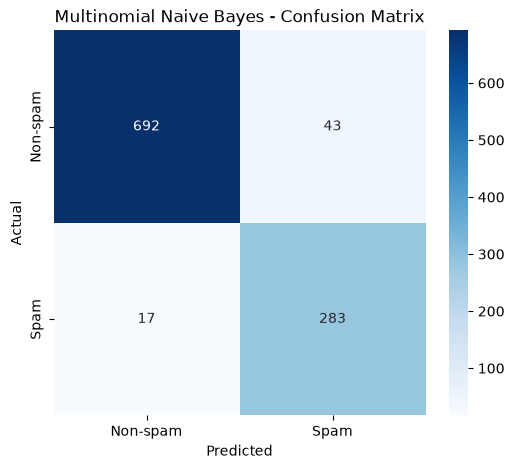

In [142]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-spam", "Spam"],
    yticklabels=["Non-spam", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multinomial Naive Bayes - Confusion Matrix")

plt.show()

In [143]:
from sklearn.linear_model import LogisticRegression
import time

start = time.perf_counter()

text_lr_model = LogisticRegression(max_iter=1000)
text_lr_model.fit(X_text_train, y_text_train)

text_lr_train_time = time.perf_counter() - start

start = time.perf_counter()

text_lr_pred = text_lr_model.predict(X_text_test)

text_lr_prediction_time = time.perf_counter() - start

print("Logistic Regression trained successfully.")
print("Training time:", text_lr_train_time, "seconds")
print("Prediction time:", text_lr_prediction_time, "seconds")

Logistic Regression trained successfully.
Training time: 30.654859000002034 seconds
Prediction time: 0.49065049999626353 seconds


In [144]:
text_lr_accuracy = accuracy_score(y_text_test, text_lr_pred)
text_lr_precision = precision_score(y_text_test, text_lr_pred)
text_lr_recall = recall_score(y_text_test, text_lr_pred)
text_lr_f1 = f1_score(y_text_test, text_lr_pred)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", text_lr_accuracy)
print("Precision:", text_lr_precision)
print("Recall   :", text_lr_recall)
print("F1-score :", text_lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.9826086956521739
Precision: 0.9577922077922078
Recall   : 0.9833333333333333
F1-score : 0.9703947368421053


In [145]:
text_lr_cm = confusion_matrix(y_text_test, text_lr_pred)

print("Confusion Matrix:")
print(text_lr_cm)

Confusion Matrix:
[[722  13]
 [  5 295]]


## Text Classification Model Comparison

In [146]:
text_results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Features": [
        X_text_train.shape[1],
        X_text_train.shape[1]
    ],
    "Accuracy": [
        nb_accuracy,
        text_lr_accuracy
    ],
    "Precision": [
        nb_precision,
        text_lr_precision
    ],
    "Recall": [
        nb_recall,
        text_lr_recall
    ],
    "F1-score": [
        nb_f1,
        text_lr_f1
    ],
    "Training Time (s)": [
        nb_train_time,
        text_lr_train_time
    ],
    "Prediction Time (s)": [
        nb_prediction_time,
        text_lr_prediction_time
    ]
})

text_results

,Model,Features,Accuracy,Precision,Recall,F1-score,Training Time (s),Prediction Time (s)
0,Multinomial Naive Bayes,3000,0.942029,0.868098,0.943333,0.904153,1.213552,0.564957
1,Logistic Regression,3000,0.982609,0.957792,0.983333,0.970395,30.654859,0.490650


### Part B Observation

The email dataset contains 5,172 emails with 3,000 existing word-count features. The dataset contains 3,672 non-spam emails and 1,500 spam emails, so the classes are imbalanced.

Two traditional machine-learning models were tested using the same features and the same train-test split. Multinomial Naive Bayes achieved 94.20% accuracy, while Logistic Regression achieved 98.26% accuracy.

Logistic Regression achieved higher accuracy, precision, recall, and F1-score in this experiment. However, its training time was much higher than Multinomial Naive Bayes. This shows a trade-off between predictive performance and computation time.

The confusion matrix of Logistic Regression shows that it correctly classified 295 of the 300 spam emails in the test set, while 5 spam emails were classified as non-spam.

The supplied Kaggle CSV is already represented using 3,000 numerical word-count features. Therefore, CountVectorizer was not applied directly to this file because raw email text is not present in the CSV.

## Part C - Improved Image Representation using Gaussian Blur

In [149]:
def extract_image_features_v2(image_path, label, use_blur=False):
    # Read image
    image = cv2.imread(str(image_path))

    if image is None:
        return None

    # Resize
    resized = cv2.resize(image, (224, 224))

    # Convert to grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # --------------------------------
    # Intensity features
    # Keep these based on original gray
    # --------------------------------
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    # --------------------------------
    # Edge representation
    # Apply blur only before Canny
    # --------------------------------
    gray_for_edges = gray

    if use_blur:
        gray_for_edges = cv2.GaussianBlur(
            gray,
            (5, 5),
            0
        )

    edges = cv2.Canny(gray_for_edges, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / gray.size

    return {
        "image": image_path.name,
        "label": label,
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

In [151]:
baseline_test = extract_image_features_v2(
    crack_images[0],
    1,
    use_blur=False
)

blur_test = extract_image_features_v2(
    crack_images[0],
    1,
    use_blur=True
)

print("Baseline edge count:", baseline_test["edge_count"])
print("Blurred edge count:", blur_test["edge_count"])

print("Baseline edge density:", baseline_test["edge_density"])
print("Blurred edge density:", blur_test["edge_density"])

Baseline edge count: 17232
Blurred edge count: 2620
Baseline edge density: 0.3434311224489796
Blurred edge density: 0.05221619897959184


In [153]:
blur_features = []

# Crack images
for image_path in crack_images:
    features = extract_image_features_v2(
        image_path,
        1,
        use_blur=True
    )

    if features is not None:
        blur_features.append(features)

# Non-crack images
for image_path in non_crack_images:
    features = extract_image_features_v2(
        image_path,
        0,
        use_blur=True
    )

    if features is not None:
        blur_features.append(features)

print("Total blurred feature rows:", len(blur_features))

Total blurred feature rows: 400


In [154]:
blur_features_df = pd.DataFrame(blur_features)

print("Shape:", blur_features_df.shape)
blur_features_df.head()

Shape: (400, 11)


,image,label,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density
0,IMG_20180513_164959951_HDR resized_448.jpg,1,122.224609,31.513482,0.003846,0.010922,23,247,121.0,2620,0.052216
1,IMG_20180513_165129852_HDR resized_448.jpg,1,131.948681,24.096114,0.002790,0.003787,8,251,133.0,1106,0.022042
2,IMG_20180513_165150613_HDR resized_448.jpg,1,121.297313,29.884272,0.013333,0.008171,2,241,121.0,3086,0.061504
3,IMG_20180513_165345878_HDR resized_448.jpg,1,130.245596,25.649018,0.001893,0.004006,20,253,131.0,1794,0.035754
4,IMG_20180513_165349788_HDR resized_448.jpg,1,131.208885,26.237598,0.002372,0.006258,11,254,132.0,1953,0.038923


In [155]:
print(blur_features_df["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


In [156]:
print("Baseline average edge count:",
      image_features_df["edge_count"].mean())

print("Blurred average edge count:",
      blur_features_df["edge_count"].mean())

print()

print("Baseline average edge density:",
      image_features_df["edge_density"].mean())

print("Blurred average edge density:",
      blur_features_df["edge_density"].mean())

Baseline average edge count: 13453.225
Blurred average edge count: 2594.2625

Baseline average edge density: 0.2681207150829082
Blurred average edge density: 0.0517032545440051


In [157]:
blur_features_df.to_csv(
    "outputs/image_features_gaussian_blur.csv",
    index=False
)

print("Improved feature table saved successfully.")

Improved feature table saved successfully.


In [158]:
X_blur = blur_features_df[feature_columns]
y_blur = blur_features_df["label"]

print("X_blur shape:", X_blur.shape)
print("y_blur shape:", y_blur.shape)

X_blur shape: (400, 9)
y_blur shape: (400,)


In [159]:
X_blur_train, X_blur_test, y_blur_train, y_blur_test = train_test_split(
    X_blur,
    y_blur,
    test_size=0.20,
    random_state=42,
    stratify=y_blur
)

print("Blurred training shape:", X_blur_train.shape)
print("Blurred testing shape:", X_blur_test.shape)

Blurred training shape: (320, 9)
Blurred testing shape: (80, 9)


In [160]:
blur_scaler = StandardScaler()

X_blur_train_scaled = blur_scaler.fit_transform(X_blur_train)
X_blur_test_scaled = blur_scaler.transform(X_blur_test)

print("Scaled blurred training shape:",
      X_blur_train_scaled.shape)

Scaled blurred training shape: (320, 9)


In [161]:
import time
from sklearn.linear_model import LogisticRegression

start = time.perf_counter()

blur_lr_model = LogisticRegression(max_iter=1000)
blur_lr_model.fit(X_blur_train_scaled, y_blur_train)

blur_lr_train_time = time.perf_counter() - start

start = time.perf_counter()

blur_lr_pred = blur_lr_model.predict(X_blur_test_scaled)

blur_lr_prediction_time = time.perf_counter() - start

blur_lr_accuracy = accuracy_score(y_blur_test, blur_lr_pred)
blur_lr_precision = precision_score(y_blur_test, blur_lr_pred)
blur_lr_recall = recall_score(y_blur_test, blur_lr_pred)
blur_lr_f1 = f1_score(y_blur_test, blur_lr_pred)

print("Blur + Logistic Regression")
print("--------------------------")
print("Accuracy :", blur_lr_accuracy)
print("Precision:", blur_lr_precision)
print("Recall   :", blur_lr_recall)
print("F1-score :", blur_lr_f1)
print("Training time:", blur_lr_train_time, "seconds")
print("Prediction time:", blur_lr_prediction_time, "seconds")

Blur + Logistic Regression
--------------------------
Accuracy : 0.925
Precision: 0.925
Recall   : 0.925
F1-score : 0.925
Training time: 0.062329799999133684 seconds
Prediction time: 0.0037100000045029446 seconds


In [162]:
from sklearn.ensemble import RandomForestClassifier

start = time.perf_counter()

blur_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

blur_rf_model.fit(X_blur_train, y_blur_train)

blur_rf_train_time = time.perf_counter() - start

start = time.perf_counter()

blur_rf_pred = blur_rf_model.predict(X_blur_test)

blur_rf_prediction_time = time.perf_counter() - start

blur_rf_accuracy = accuracy_score(y_blur_test, blur_rf_pred)
blur_rf_precision = precision_score(y_blur_test, blur_rf_pred)
blur_rf_recall = recall_score(y_blur_test, blur_rf_pred)
blur_rf_f1 = f1_score(y_blur_test, blur_rf_pred)

print("Blur + Random Forest")
print("--------------------")
print("Accuracy :", blur_rf_accuracy)
print("Precision:", blur_rf_precision)
print("Recall   :", blur_rf_recall)
print("F1-score :", blur_rf_f1)
print("Training time:", blur_rf_train_time, "seconds")
print("Prediction time:", blur_rf_prediction_time, "seconds")

Blur + Random Forest
--------------------
Accuracy : 0.95
Precision: 0.95
Recall   : 0.95
F1-score : 0.95
Training time: 1.7092761999956565 seconds
Prediction time: 0.19346730000688694 seconds


In [163]:
blur_lr_cm = confusion_matrix(y_blur_test, blur_lr_pred)
blur_rf_cm = confusion_matrix(y_blur_test, blur_rf_pred)

print("Blur + Logistic Regression:")
print(blur_lr_cm)

print("\nBlur + Random Forest:")
print(blur_rf_cm)

Blur + Logistic Regression:
[[37  3]
 [ 3 37]]

Blur + Random Forest:
[[38  2]
 [ 2 38]]


In [164]:
reduced_features = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

X_reduced = image_features_df[reduced_features]
y_reduced = image_features_df["label"]

print("Original number of features:", len(feature_columns))
print("Reduced number of features:", len(reduced_features))
print("Reduced X shape:", X_reduced.shape)

Original number of features: 9
Reduced number of features: 6
Reduced X shape: (400, 6)


In [165]:
X_reduced_train = X_reduced.loc[X_train.index]
X_reduced_test = X_reduced.loc[X_test.index]

y_reduced_train = y_reduced.loc[y_train.index]
y_reduced_test = y_reduced.loc[y_test.index]

print("Reduced training shape:", X_reduced_train.shape)
print("Reduced testing shape:", X_reduced_test.shape)

print("\nTraining labels:")
print(y_reduced_train.value_counts())

print("\nTesting labels:")
print(y_reduced_test.value_counts())

Reduced training shape: (320, 6)
Reduced testing shape: (80, 6)

Training labels:
label
1    160
0    160
Name: count, dtype: int64

Testing labels:
label
0    40
1    40
Name: count, dtype: int64


In [166]:
reduced_scaler = StandardScaler()

X_reduced_train_scaled = reduced_scaler.fit_transform(
    X_reduced_train
)

X_reduced_test_scaled = reduced_scaler.transform(
    X_reduced_test
)

print("Scaled reduced training shape:",
      X_reduced_train_scaled.shape)

Scaled reduced training shape: (320, 6)


In [167]:
start = time.perf_counter()

reduced_lr_model = LogisticRegression(max_iter=1000)
reduced_lr_model.fit(
    X_reduced_train_scaled,
    y_reduced_train
)

reduced_lr_train_time = time.perf_counter() - start

start = time.perf_counter()

reduced_lr_pred = reduced_lr_model.predict(
    X_reduced_test_scaled
)

reduced_lr_prediction_time = time.perf_counter() - start

reduced_lr_accuracy = accuracy_score(
    y_reduced_test,
    reduced_lr_pred
)

reduced_lr_precision = precision_score(
    y_reduced_test,
    reduced_lr_pred
)

reduced_lr_recall = recall_score(
    y_reduced_test,
    reduced_lr_pred
)

reduced_lr_f1 = f1_score(
    y_reduced_test,
    reduced_lr_pred
)

print("Reduced Features + Logistic Regression")
print("---------------------------------------")
print("Accuracy :", reduced_lr_accuracy)
print("Precision:", reduced_lr_precision)
print("Recall   :", reduced_lr_recall)
print("F1-score :", reduced_lr_f1)
print("Training time:", reduced_lr_train_time, "seconds")
print("Prediction time:", reduced_lr_prediction_time, "seconds")

Reduced Features + Logistic Regression
---------------------------------------
Accuracy : 0.925
Precision: 0.925
Recall   : 0.925
F1-score : 0.925
Training time: 0.05917269999918062 seconds
Prediction time: 0.003114499995717779 seconds


In [168]:
start = time.perf_counter()

reduced_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

reduced_rf_model.fit(
    X_reduced_train,
    y_reduced_train
)

reduced_rf_train_time = time.perf_counter() - start

start = time.perf_counter()

reduced_rf_pred = reduced_rf_model.predict(
    X_reduced_test
)

reduced_rf_prediction_time = time.perf_counter() - start

reduced_rf_accuracy = accuracy_score(
    y_reduced_test,
    reduced_rf_pred
)

reduced_rf_precision = precision_score(
    y_reduced_test,
    reduced_rf_pred
)

reduced_rf_recall = recall_score(
    y_reduced_test,
    reduced_rf_pred
)

reduced_rf_f1 = f1_score(
    y_reduced_test,
    reduced_rf_pred
)

print("Reduced Features + Random Forest")
print("---------------------------------")
print("Accuracy :", reduced_rf_accuracy)
print("Precision:", reduced_rf_precision)
print("Recall   :", reduced_rf_recall)
print("F1-score :", reduced_rf_f1)
print("Training time:", reduced_rf_train_time, "seconds")
print("Prediction time:", reduced_rf_prediction_time, "seconds")

Reduced Features + Random Forest
---------------------------------
Accuracy : 0.95
Precision: 0.95
Recall   : 0.95
F1-score : 0.95
Training time: 1.7232981999986805 seconds
Prediction time: 0.08048410000628792 seconds


In [169]:
reduced_lr_cm = confusion_matrix(
    y_reduced_test,
    reduced_lr_pred
)

reduced_rf_cm = confusion_matrix(
    y_reduced_test,
    reduced_rf_pred
)

print("Reduced Logistic Regression:")
print(reduced_lr_cm)

print("\nReduced Random Forest:")
print(reduced_rf_cm)

Reduced Logistic Regression:
[[37  3]
 [ 3 37]]

Reduced Random Forest:
[[38  2]
 [ 2 38]]


## Part C - Final Comparison

The baseline image representation uses 9 hand-crafted features. Two representation changes were tested: Gaussian Blur before Canny edge detection, and feature reduction from 9 features to 6 features.

The table below compares the original and modified representations using the same traditional machine-learning models.

In [ ]:
part_c_results = pd.DataFrame({
    "Representation": [
        "Baseline - 9 features",
        "Gaussian Blur - 9 features",
        "Reduced - 6 features",
        "Baseline - 9 features",
        "Gaussian Blur - 9 features",
        "Reduced - 6 features"
    ],
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest",
        "Random Forest"
    ],
    "Number of Features": [9, 9, 6, 9, 9, 6],
    "Accuracy": [
        accuracy,
        blur_lr_accuracy,
        reduced_lr_accuracy,
        rf_accuracy,
        blur_rf_accuracy,
        reduced_rf_accuracy
    ],
    "Precision": [
        precision,
        blur_lr_precision,
        reduced_lr_precision,
        rf_precision,
        blur_rf_precision,
        reduced_rf_precision
    ],
    "Recall": [
        recall,
        blur_lr_recall,
        reduced_lr_recall,
        rf_recall,
        blur_rf_recall,
        reduced_rf_recall
    ],
    "F1-score": [
        f1,
        blur_lr_f1,
        reduced_lr_f1,
        rf_f1,
        blur_rf_f1,
        reduced_rf_f1
    ],
    "Training Time (s)": [
        train_time,
        blur_lr_train_time,
        reduced_lr_train_time,
        rf_train_time,
        blur_rf_train_time,
        reduced_rf_train_time
    ],
    "Prediction Time (s)": [
        prediction_time,
        blur_lr_prediction_time,
        reduced_lr_prediction_time,
        rf_prediction_time,
        blur_rf_prediction_time,
        reduced_rf_prediction_time
    ]
})

part_c_results = part_c_results.round(4)
display(part_c_results)

part_c_results.to_csv("outputs/part_c_results.csv", index=False)
print("Part C results saved to outputs/part_c_results.csv")

### Part C Observation

Gaussian Blur was tested before Canny edge detection. It greatly reduced the detected edge count, but it did not improve classification performance: Logistic Regression changed from 93.75% to 92.50% accuracy, while Random Forest remained at 95.00%.

A second experiment reduced the image representation from 9 features to 6 features by removing minimum intensity, maximum intensity, and median intensity. Logistic Regression changed from 93.75% to 92.50% accuracy, while Random Forest remained at 95.00%. The reduced representation also used fewer features and showed lower measured Random Forest model training and prediction time in this run.

Therefore, the feature-reduction experiment is used as the main Part C improvement because it reduced feature dimensionality while maintaining the Random Forest classification metrics in this experiment. Gaussian Blur is retained as an evaluated alternative, but its classification results did not improve over the baseline.

### Overall Lab Conclusion

This lab demonstrated how raw images and pre-vectorized text data can be converted into numerical representations for traditional machine-learning classification. For the asphalt images, intensity statistics and Canny edge features were used with Logistic Regression and Random Forest. For the email dataset, the supplied Kaggle CSV already contained 3,000 word-count features, so those numerical features were used directly with Multinomial Naive Bayes and Logistic Regression. The experiments also showed the trade-off between predictive performance, feature dimensionality, and computation time.

### Dataset Representation Note

The supplied Kaggle `emails.csv` contains numerical word-count features rather than raw email text. Therefore, the 3,000 columns used in Part B were not generated by CountVectorizer in this notebook. This limitation is documented rather than treating the existing columns as newly vectorized text.